In [1]:
from ai_edge_litert.interpreter import Interpreter
interpreter_detect = Interpreter(model_path="palm_detection_full.tflite")
interpreter_detect.allocate_tensors()

# Get input and output details
input_details_detect = interpreter_detect.get_input_details()
output_details_detect = interpreter_detect.get_output_details()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [2]:
input_details_detect

[{'name': 'input_1',
  'index': 0,
  'shape': array([  1, 192, 192,   3], dtype=int32),
  'shape_signature': array([  1, 192, 192,   3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [3]:
import numpy as np

import anchorlib

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def decode_best_palm_detection(raw_boxes, raw_scores):
    """
    raw_boxes:  (1, 2016, 18) - raw regression output from palm detector
    raw_scores: (1, 2016, 1)  - raw logit scores from palm detector

    Returns the decoded box and keypoints (in pixels) for the highest-confidence anchor.
    """
    input_size = 192.0

    # --- Strip batch dimension ---
    boxes  = raw_boxes[0]   # (2016, 18)
    scores = raw_scores[0]  # (2016, 1)

    # --- Find highest confidence anchor ---
    confidences = sigmoid(scores[:, 0])   # (2016,) - convert logits to probabilities
    best_idx = np.argmax(confidences)
    best_conf = confidences[best_idx]

    print(f"Best anchor index: {best_idx}")
    print(f"Confidence: {best_conf:.4f}")

    # --- Retrieve the corresponding anchor and raw prediction ---
    anchors = anchorlib.generate_anchors(anchorlib.PALM_DETECTION_OPTIONS)
    anchor  = anchors[best_idx]           # [x_center, y_center, w, h] normalized
    raw     = boxes[best_idx]             # (18,)

    # Anchor center in pixels
    ax = anchor.x_center * input_size
    ay = anchor.y_center * input_size

    # --- Decode box (dy, dx, h, w) ---
    dy, dx, h, w = raw[0], raw[1], raw[2], raw[3]
    box = {
        'x_center': ax + dx,
        'y_center': ay + dy,
        'width':    w,
        'height':   h,
        # Convenience: corners
        'x_min':    ax + dx - w / 2,
        'y_min':    ay + dy - h / 2,
        'x_max':    ax + dx + w / 2,
        'y_max':    ay + dy + h / 2,
    }

    # --- Decode 7 keypoints ---
    # Each is a (dx, dy) offset from the same anchor center
    keypoint_names = [
        'wrist',
        'pinky_mcp',
        'index_mcp',
        'middle_tip',
        'index_tip',
        'thumb_tip',
        'thumb_mcp',
    ]
    keypoints = {}
    for i, name in enumerate(keypoint_names):
        kp_dx = raw[4 + 2*i]
        kp_dy = raw[4 + 2*i + 1]
        keypoints[name] = (ax + kp_dx, ay + kp_dy)

    return best_conf, box, keypoints


In [4]:
import cv2
import numpy as np

def draw_palm_detection(image, box, keypoints, conf):
    """
    image:     numpy array (H, W, 3) - the original input image (any size)
    box:       dict with x_center, y_center, width, height, x_min, y_min, x_max, y_max
               all in 192x192 pixel space
    keypoints: dict of name -> (x, y) in 192x192 pixel space
    conf:      float confidence score
    """
    h, w = image.shape[:2]

    # Scale factor from 192x192 detection space back to original image size
    sx = w / 192.0
    sy = h / 192.0

    def scale(x, y):
        return (int(x * sx), int(y * sy))

    vis = image.copy()

    # --- Bounding box ---
    x_min, y_min = scale(box['x_min'], box['y_min'])
    x_max, y_max = scale(box['x_max'], box['y_max'])
    cv2.rectangle(vis, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)

    # --- Confidence label ---
    label = f"palm {conf:.2f}"
    cv2.putText(vis, label, (x_min, y_min - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --- Keypoints ---
    colors = {
        'wrist':      (255,   0,   0),
        'pinky_mcp':  (255, 128,   0),
        'index_mcp':  (255, 255,   0),
        'middle_tip': (  0, 255,   0),
        'index_tip':  (  0, 255, 255),
        'thumb_tip':  (  0,   0, 255),
        'thumb_mcp':  (128,   0, 255),
    }
    for name, (kx, ky) in keypoints.items():
        pt = scale(kx, ky)
        cv2.circle(vis, pt, radius=4, color=colors[name], thickness=-1)
        cv2.putText(vis, name, (pt[0] + 5, pt[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, colors[name], 1)

    # --- Skeleton: connect wrist to MCP joints ---
    connections = [
        ('wrist', 'pinky_mcp'),
        ('wrist', 'index_mcp'),
        ('wrist', 'thumb_mcp'),
        # ('index_mcp', 'pinky_mcp'),
    ]
    for a, b in connections:
        pt_a = scale(*keypoints[a])
        pt_b = scale(*keypoints[b])
        cv2.line(vis, pt_a, pt_b, color=(200, 200, 200), thickness=1)

    return vis

In [5]:
import numpy as np

def detect(image):
    from PIL import Image

    image_np = np.array(image, dtype=np.uint8)
    input_data = image_np.astype(np.float32) / 255.0
                      
    input_data = np.expand_dims(input_data, axis=0)
    interpreter_detect.set_tensor(input_details_detect[0]['index'], input_data)
    interpreter_detect.invoke()

    output_0 = interpreter_detect.get_tensor(output_details_detect[0]['index'])
    output_1 = interpreter_detect.get_tensor(output_details_detect[1]['index'])

    best_conf, box, keypoints = decode_best_palm_detection(output_0, output_1)
    return best_conf, box, keypoints

def detect_display(path):
    from PIL import Image

    image = Image.open(path).resize((192, 192))
    best_conf, box, keypoints = detect(image)

    vis = draw_palm_detection(np.array(image, dtype=np.uint8), box, keypoints, float(best_conf))
    from IPython.display import display
    from PIL import Image
    
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(vis))

Best anchor index: 1615
Confidence: 0.9681


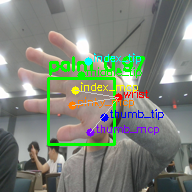

Best anchor index: 1693
Confidence: 0.9527


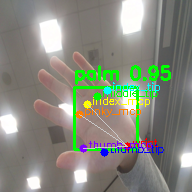

Best anchor index: 1551
Confidence: 0.9781


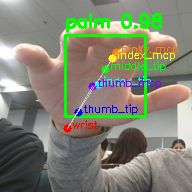

In [6]:
detect_display("IMG_1772308005.jpg")
detect_display("IMG_20260228_100522.jpg")
detect_display("IMG_1772308279_HDR+.jpg")

In [7]:
interpreter_landmark = Interpreter(model_path="hand_landmark_full.tflite")
interpreter_landmark.allocate_tensors()

# Get input and output details
input_details_landmark = interpreter_landmark.get_input_details()
output_details_landmark = interpreter_landmark.get_output_details()

In [8]:
input_details_landmark

[{'name': 'input_1',
  'index': 0,
  'shape': array([  1, 224, 224,   3], dtype=int32),
  'shape_signature': array([  1, 224, 224,   3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [9]:
output_details_landmark

[{'name': 'Identity',
  'index': 165,
  'shape': array([ 1, 63], dtype=int32),
  'shape_signature': array([ 1, 63], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}},
 {'name': 'Identity_1',
  'index': 164,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([1, 1], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}},
 {'name': 'Identity_2',
  'index': 162,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([1, 1], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_p

In [42]:
import numpy as np
import cv2

# ── Landmark connections (finger skeletons) ──────────────────────────────────
HAND_CONNECTIONS = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),
    # Index
    (0, 5), (5, 6), (6, 7), (7, 8),
    # Middle
    (0, 9), (9, 10), (10, 11), (11, 12),
    # Ring
    (0, 13), (13, 14), (14, 15), (15, 16),
    # Pinky
    (0, 17), (17, 18), (18, 19), (19, 20),
    # Palm
    (5, 9), (9, 13), (13, 17),
]

LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]


def parse_landmarks(output_63: np.ndarray):
    """
    Convert flat [63] array of interleaved x,y,z values into
    a list of 21 (px, py, z) tuples.
    x and y are normalized [0,1] -> scaled to image pixels.
    z is depth relative to wrist (not scaled).
    """
    coords = output_63.reshape(21, 3)  # shape (21, 3)
    landmarks = []
    for x, y, z in coords:
        landmarks.append((x, y, float(z)))
    return landmarks


def draw_landmarks(image: np.ndarray, landmarks: list, draw_labels: bool = True):
    """
    Draw hand skeleton and landmark points over image (in-place).
    """
    img = image.copy()
    h, w = img.shape[:2]

    # Draw connections
    for (a, b) in HAND_CONNECTIONS:
        x1, y1, _ = landmarks[a]
        x1 = int(x1)
        y1 = int(y1)
        x2, y2, _ = landmarks[b]
        x2 = int(x2)
        y2 = int(y2)
        cv2.line(img, (x1, y1), (x2, y2), color=(0, 200, 0), thickness=2)

    # Draw landmark dots and labels
    for i, (px, py, z) in enumerate(landmarks):
        px = int(px)
        py = int(py)
        # Fingertips (indices 4,8,12,16,20) get a larger dot
        is_tip = i in (4, 8, 12, 16, 20)
        radius = 6 if is_tip else 4
        color = (0, 0, 255) if is_tip else (255, 0, 0)
        cv2.circle(img, (px, py), radius, color, -1)
        cv2.circle(img, (px, py), radius, (255, 255, 255), 1)  # white outline

        if draw_labels:
            label = f"{i}"  # just the index; swap for LANDMARK_NAMES[i] if you want full names
            cv2.putText(img, label, (px + 6, py - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    return img

In [43]:
def landmark(image):
    from PIL import Image
    import numpy as np
    image_np = np.array(image, dtype=np.uint8)
    input_data = image_np.astype(np.float32) / 255.0
                      
    input_data = np.expand_dims(input_data, axis=0)
    interpreter_landmark.set_tensor(input_details_landmark[0]['index'], input_data)
    interpreter_landmark.invoke()

    landmarks = interpreter_landmark.get_tensor(output_details_landmark[0]['index'])[0]
    hand_prescence = interpreter_landmark.get_tensor(output_details_landmark[1]['index'])
    handedness = interpreter_landmark.get_tensor(output_details_landmark[2]['index'])
    world_landmarks = interpreter_landmark.get_tensor(output_details_landmark[3]['index'])

    vis = draw_landmarks(image_np, parse_landmarks(landmarks), True)
    display(Image.fromarray(vis))

def landmark_display(path):
    from PIL import Image

    image = Image.open(path).resize((224, 224))
    _ = landmark(image)

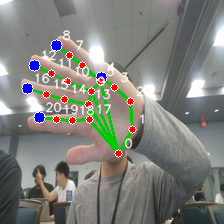

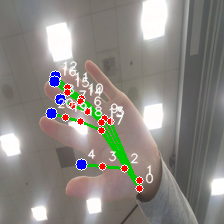

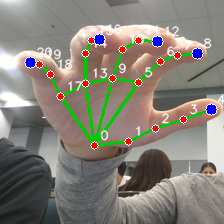

In [44]:
landmark_display("IMG_1772308005.jpg")
landmark_display("IMG_20260228_100522.jpg")
landmark_display("IMG_1772308279_HDR+.jpg")